# 1.数据导入

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import pickle
import time
# 绘图
# 1. 确定画布
from matplotlib import pyplot as plt
#新增加的两行
import matplotlib

# 设置英文字体和数字字体


from __future__ import absolute_import, division, print_function
#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows',None)
def process_folder(folder_path):
    # Create an empty DataFrame to store the results
    result = pd.DataFrame()

    # Loop through all files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(".xlsx"):
            # Read the file and apply the function
            file_path = os.path.join(folder_path, filename)
            data = pd.read_excel(file_path)
            result = pd.concat([result,data], axis=0,ignore_index=False)
            # Append the results to the final DataFrame
#             result = result.insert(data)

    # Return the final DataFrame
    return result

#显示所有列
pd.set_option('display.max_columns', None)
#显示所有行
pd.set_option('display.max_rows',None)


########特征提取
data=pd.read_excel("F:\\A研究生实验\\小论文结果\\小论文1\\数据20240524\\4.特征筛选\\第二次筛选剔除相关性强且原始变量一致后的数据集.xlsx")


###########全时序指数
#data=pd.read_excel("F:\\A研究生实验\\小论文结果\\小论文1\\数据20240524\\3-2四省时序指数\\全时序指数.xlsx")

data.head(3)

,code,start,end,yield,NDVI_INT_H,NDVI_MEAN_H,NDVI_CR_F,NDVI_PER90,NDWI_MAX,NDWI_MEAN,NDWI_INT_H,NDWI_MEAN_H,NDWI_CR_GH,NDWI_CR_F,NDWI_MEAN_F,NDWI_PER90,NDWI_MEAN_E,NDWI_MEAN_O,NDWI_AMP,NDWI_AMP_T
0,370725,2015,2016,6715.999999,1.543074,0.510011,-0.086089,0.489601,0.062493,-0.005649,0.136162,0.043485,0.044804,-0.026438,0.041936,0.050473,0.002267,-0.025857,0.112109,121
1,370724,2015,2016,5242.999999,1.524425,0.509063,-0.069564,0.502380,0.086797,-0.014052,0.084357,0.026319,0.058428,-0.015255,0.032085,0.034223,0.002670,-0.034204,0.148378,152
2,370786,2015,2016,6703.999999,1.737142,0.573201,-0.136540,0.547062,0.083890,-0.003436,0.210871,0.067524,0.078639,-0.039858,0.061338,0.070107,-0.005392,-0.031232,0.133751,101


# 2.训练集

In [2]:

data_2021_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2019,2020])]
data_2021_test=data[data['end'].isin([2021])]

data_2020_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2019,2021])]
data_2020_test=data[data['end'].isin([2020])]

data_2019_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2020,2021])]
data_2019_test=data[data['end'].isin([2019])]

data_2018_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2019,2020,2021])]
data_2018_test=data[data['end'].isin([2018])]

data_2017_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2018,2019,2020,2021])]
data_2017_test=data[data['end'].isin([2017])]

data_2016_train=data[data['end'].isin([2011,2012,2013,2014,2015,2017,2018,2019,2020,2021])]
data_2016_test=data[data['end'].isin([2016])]

data_2015_train=data[data['end'].isin([2011,2012,2013,2014,2016,2017,2018,2019,2020,2021])]
data_2015_test=data[data['end'].isin([2015])]

data_2014_train=data[data['end'].isin([2011,2012,2013,2016,2015,2017,2018,2019,2020,2021])]
data_2014_test=data[data['end'].isin([2014])]

data_2013_train=data[data['end'].isin([2011,2012,2016,2014,2015,2017,2018,2019,2020,2021])]
data_2013_test=data[data['end'].isin([2013])]

data_2012_train=data[data['end'].isin([2011,2016,2013,2014,2015,2017,2018,2019,2020,2021])]
data_2012_test=data[data['end'].isin([2012])]

data_2011_train=data[data['end'].isin([2016,2012,2013,2014,2015,2017,2018,2019,2020,2021])]
data_2011_test=data[data['end'].isin([2011])]





data_20_21_train=data[data['end'].isin([2011,2012,2013,2014,2015,2016,2017,2018,2019])]
data_20_21_test=data[data['end'].isin([2020,2021])]

data_20_21_test.shape

(769, 20)

In [3]:
data_20_21_train.reset_index(drop=True, inplace=True)
data_20_21_test.reset_index(drop=True, inplace=True)

In [54]:
data_jiangsu_test=data_2021_test[data_2021_test['省'].isin(['Jiangsu Province'])]
data_shandong_test=data_2021_test[data_2021_test['省'].isin(['Shandong Province'])]
data_henan_test=data_2021_test[data_2021_test['省'].isin(['Henan Province'])]
data_anhui_test=data_2021_test[data_2021_test['省'].isin(['Anhui Province'])]

# 3.XGBOOST

训练集的CCC: 0.91
训练集的var_y_train: 1600695.88
训练集的var_y_pred_train: 1126772.62
训练集的mean_y_train: 5662.30
训练集的mean_y_pred_train: 5662.52
验证集的CCC: 0.74
验证集的var_y_val: 1229529.63
验证集的var_y_pred: 1060515.50
验证集的mean_y_val: 5887.46
验证集的mean_y_pred: 5702.12


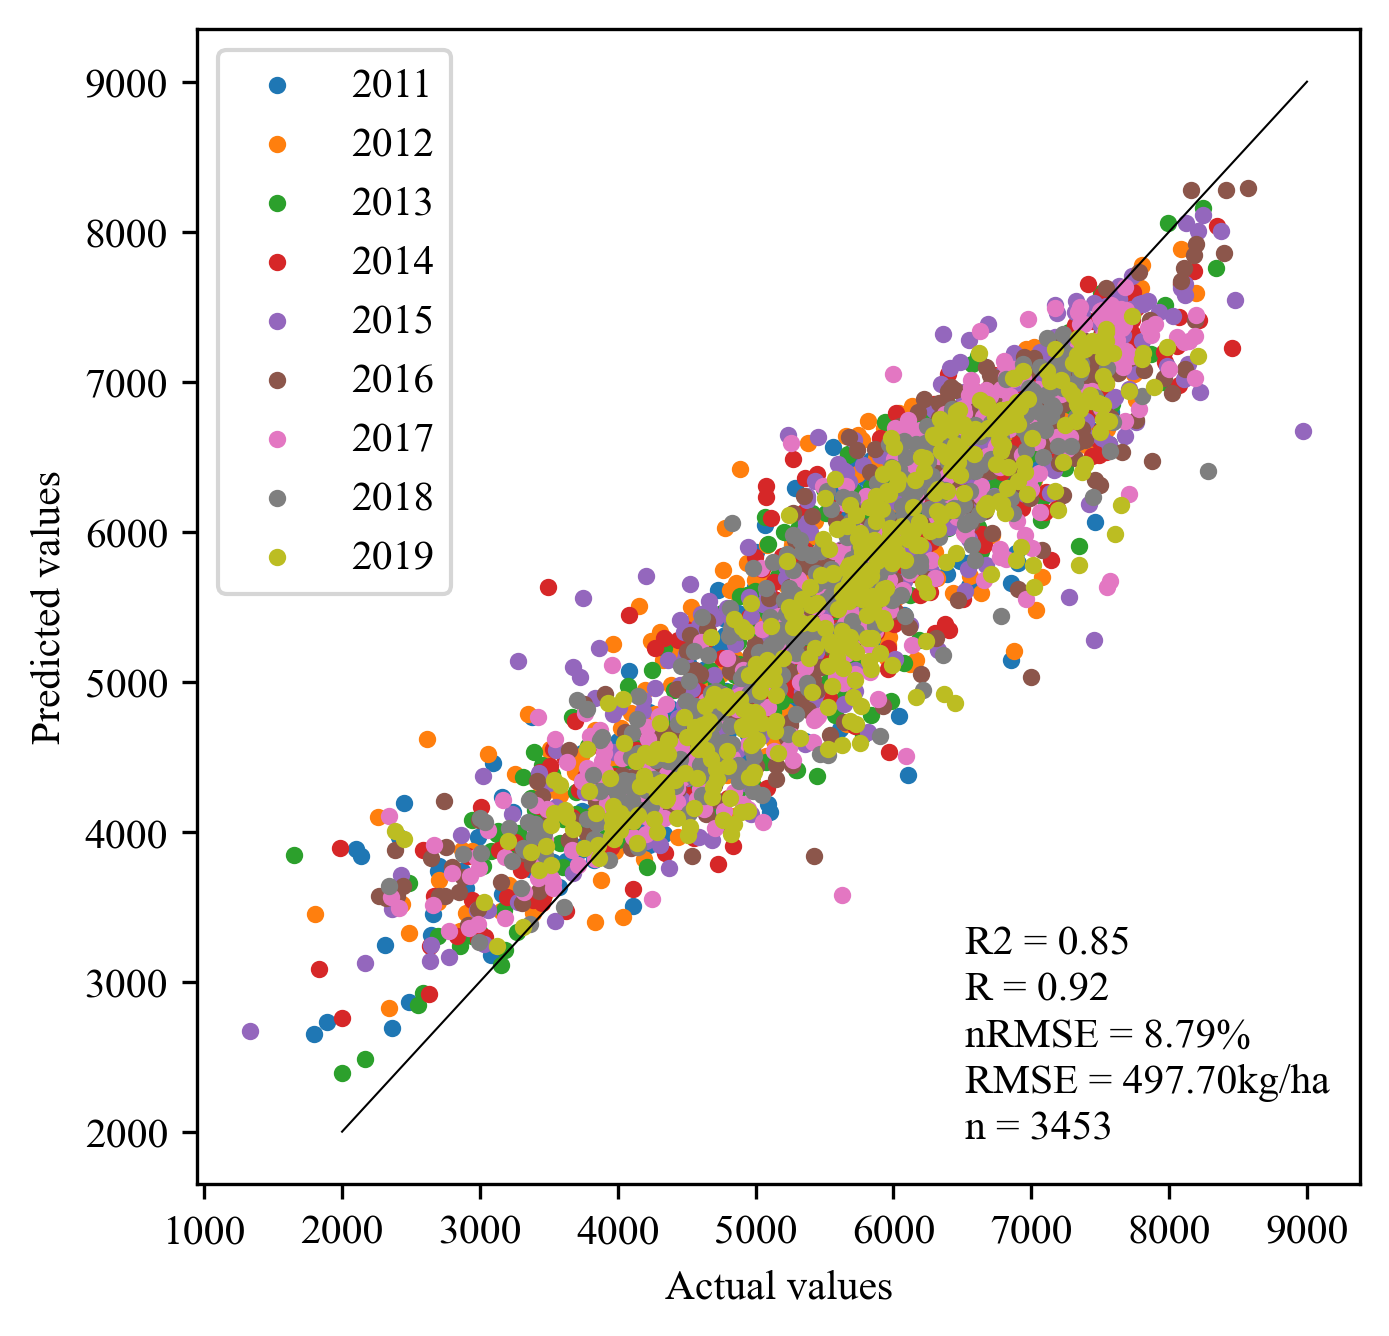

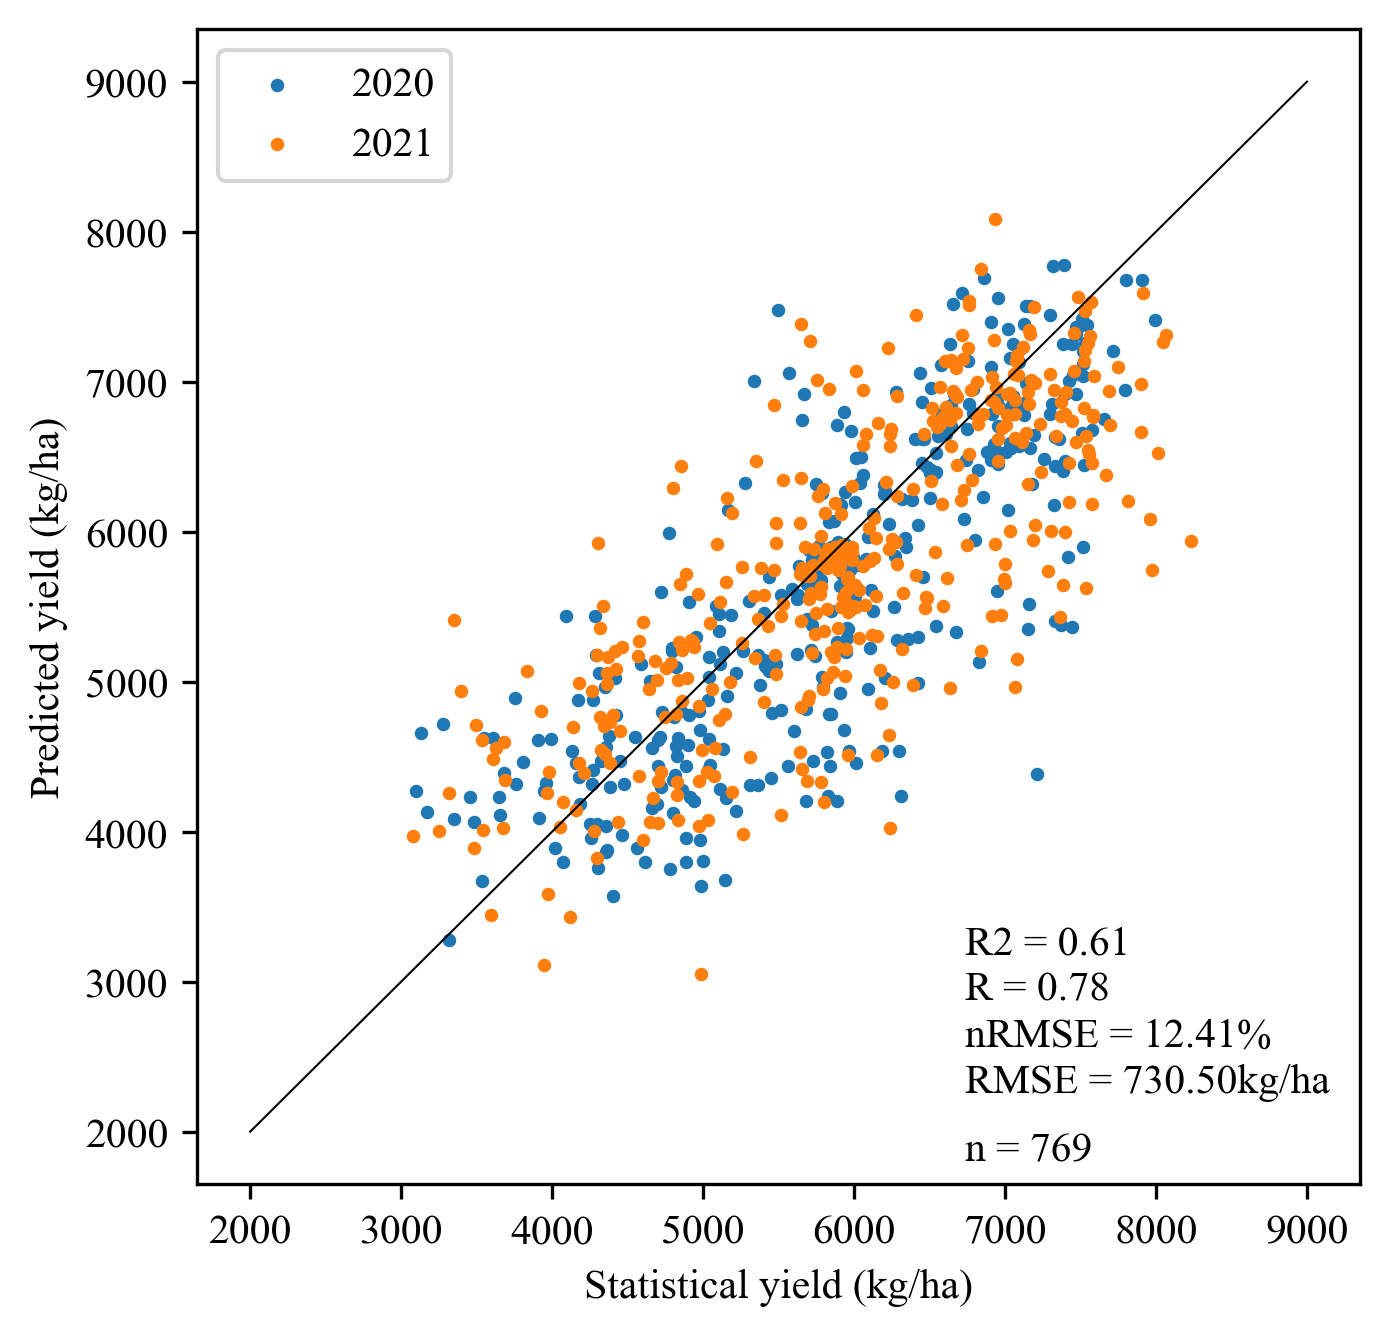

In [3]:
import xgboost as xgb
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import r2_score
import math
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
# matplotlib.rcParams['font.sans-serif'] = ['Times New Roman']
# matplotlib.rc("font",family='FangSong')
df=data
train_data= data_20_21_train
test_data=data_20_21_test
val_data=test_data
################################################################################时序特征
X_train = train_data.iloc[:, np.r_[4:20]].values
y_train = train_data.iloc[:, 3].values
X_val = test_data.iloc[:, np.r_[4:20]].values
y_val = test_data.iloc[:, 3].values

####################################################################################全时序指数
# X_train = train_data.iloc[:, np.r_[4:54]].values
# y_train = train_data.iloc[:, 3].values
# X_val = test_data.iloc[:, np.r_[4:54]].values
# y_val = test_data.iloc[:, 3].values




# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val= scaler.transform(X_val)
X_train =StandardScaler().fit(X_train).transform(X_train)
X_val =StandardScaler().fit(X_val).transform(X_val)
##################################归一化
# X_train =MinMaxScaler().fit(X_train).transform(X_train)
# X_val =MinMaxScaler().fit(X_val).transform(X_val)



model=xgb.XGBRegressor(n_estimators=26,learning_rate=0.2,max_depth=6)#20_21

#model=xgb.XGBRegressor(n_estimators=12,learning_rate=0.28,max_depth=6)#2011
#model=xgb.XGBRegressor(n_estimators=10,learning_rate=0.277,max_depth=6)#2012
#model=xgb.XGBRegressor(n_estimators=20,learning_rate=0.245,max_depth=6)#2013
#model=xgb.XGBRegressor(n_estimators=16,learning_rate=0.402,max_depth=6)#2014
#model=xgb.XGBRegressor(n_estimators=10,learning_rate=0.157,max_depth=6)#2015
#model=xgb.XGBRegressor(n_estimators=86,learning_rate=0.293,max_depth=6)#2016
#model=xgb.XGBRegressor(n_estimators=42,learning_rate=0.24,max_depth=6)#2017
#model=xgb.XGBRegressor(n_estimators=10,learning_rate=0.176,max_depth=6)#2018
#model=xgb.XGBRegressor(n_estimators=10,learning_rate=0.25,max_depth=6)#2019
#model=xgb.XGBRegressor(n_estimators=20,learning_rate=0.183,max_depth=6)#2020
#model=xgb.XGBRegressor(n_estimators=14,learning_rate=0.187,max_depth=6)#2021
model.fit(X_train, y_train)

# 在验证集上进行预测
y_pred = model.predict(X_val)
y_pred_train = model.predict(X_train)
# # 评估模型性能
# r2 = r2_score(y_val, y_pred)
# print(f"验证集 R-squared score: {r2:.5f}")

# 计算建模集和验证集的R^2
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_val, y_pred)
# mse = mean_squared_error(y_val, y_pred)
# print(f"验证集均方误差 Mean squared error: {mse:.3f}")

# mae = mean_absolute_error(y_val, y_pred)
# print(f"验证集平均绝对误差 Mean absolute error: {mae:.3f}")

# Calculate RMSE and nRMSE
def calculate_rmse(predictions, actual_values):
    return np.sqrt(np.mean((predictions - actual_values) ** 2))
rmse = calculate_rmse(y_pred, y_val)
nrmse = rmse / np.mean(y_val)

def calculate_mre(y_true, y_pred):
    n = len(y_true)
    mre = (1/n) * np.sum(np.abs((y_true - y_pred) / np.abs(y_true)))
    return mre

mre = calculate_mre(y_val, y_pred)
# print(f"验证集均一化均方根误差 nRMSE: {nrmse:.3f}")
# Calculate RMSE and nRMSE
rmse_train = calculate_rmse(y_pred_train, y_train)
nrmse_train = rmse_train / np.mean(y_train)
#R值越接近1代表y_val和y_pred之间的线性关系越强，越接近1:1线。
r = np.corrcoef(y_val, y_pred)[0, 1]
r2=r*r

# print(f"验证集 相关系数 r: {r:.3f}")
#训练集相关系数
r_train=np.corrcoef(y_train, y_pred_train)[0, 1]
r2_train=r_train*r_train
# train_r2 = rf_model.score(X_train, y_train)
# print(f"训练集 模型拟合程度R-squared score: {train_r2:.3f}")

# 计算训练集的CCC
r2_train = r2_score(y_train, y_pred_train)
r_train = np.sqrt(r2_train)
var_y_train = np.var(y_train)
var_y_pred_train = np.var(y_pred_train)
mean_y_train = np.mean(y_train)
mean_y_pred_train = np.mean(y_pred_train)
ccc_train = 2 * r_train * np.sqrt(var_y_train * var_y_pred_train) / (var_y_train + var_y_pred_train + (mean_y_train - mean_y_pred_train)**2)
print(f"训练集的CCC: {ccc_train:.2f}")
print(f"训练集的var_y_train: {var_y_train:.2f}")
print(f"训练集的var_y_pred_train: {var_y_pred_train:.2f}")
print(f"训练集的mean_y_train: {mean_y_train:.2f}")
print(f"训练集的mean_y_pred_train: {mean_y_pred_train:.2f}")
# 计算验证集的CCC
r2_val = r2_score(y_val, y_pred)
r_val = np.sqrt(r2_val)
var_y_val = np.var(y_val)
var_y_pred = np.var(y_pred)
mean_y_val = np.mean(y_val)
mean_y_pred = np.mean(y_pred)
ccc_val = 2 * r_val * np.sqrt(var_y_val * var_y_pred) / (var_y_val + var_y_pred + (mean_y_val - mean_y_pred)**2)
print(f"验证集的CCC: {ccc_val:.2f}")
print(f"验证集的var_y_val: {var_y_val:.2f}")
print(f"验证集的var_y_pred: {var_y_pred:.2f}")
print(f"验证集的mean_y_val: {mean_y_val:.2f}")
print(f"验证集的mean_y_pred: {mean_y_pred:.2f}")
year_train = sorted(train_data['end'].unique())
# 创建一个新的图形并设置其大小
fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
# 绘制建模集散点图
# ax.scatter(y_train, y_pred_train)
for year in year_train:
    train_data_year = train_data[train_data['end'] == year]
    y_train_year = y_train[train_data['end'] == year]
    y_pred_train_year = y_pred_train[train_data['end'] == year]
    ax.scatter(y_train_year, y_pred_train_year, s=10,label=year)
ax.set_xlabel('Actual values')
ax.set_ylabel('Predicted values')
# ax.set_title('train data')

# ax.set(facecolor = "white")#修改背景图颜色
# 显示其他信息
# ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_train), transform=ax.transAxes)
ax.text(0.66, 0.20, 'R2 = {:.2f}'.format(r2_train), transform=ax.transAxes,size=10)
ax.text(0.66, 0.16, 'R = {:.2f}'.format(r_train), transform=ax.transAxes)
ax.text(0.66, 0.12, 'nRMSE = {:.2%}'.format(nrmse_train), transform=ax.transAxes)
ax.text(0.66, 0.08, 'RMSE = {:.2f}kg/ha'.format(rmse_train), transform=ax.transAxes)
# 添加点的个数标注
n = len(y_train)
ax.text(0.66, 0.04, f'n = {n}', transform=ax.transAxes)
# 计算趋势线的斜率和截距
slope, intercept = np.polyfit(y_train, y_pred_train, 1)
# 绘制趋势线
# ax.plot(y_train, slope * np.array(y_train) + intercept, color='red', label='Trendline')
# 绘制1:1线
ax.plot([2000, 9000], [2000, 9000], ls='-', c='k',linewidth=0.5)
# 添加图例
ax.legend()
# 显示图形
plt.show()




year_val = sorted(val_data['end'].unique())
# 创建一个新的图形并设置其大小
fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
#分色绘制散点图
for year in year_val:
    val_data_year = val_data[val_data['end'] == year]
    y_val_year = y_val[val_data['end'] == year]
    y_pred_val_year = y_pred[val_data['end'] == year]
    ax.scatter(y_val_year, y_pred_val_year, s=5,label=year)
# 绘制验证集散点图
# ax.scatter(y_test, y_pred_test)
ax.set_xlabel('Statistical yield (kg/ha)')
ax.set_ylabel('Predicted yield (kg/ha)')
# ax.set_title('test data')
# 显示其他信息
# ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_test), transform=ax.transAxes)
ax.text(0.66, 0.20, 'R2 = {:.2f}'.format(r2), transform=ax.transAxes,size=10)
ax.text(0.66, 0.16, 'R = {:.2f}'.format(r), transform=ax.transAxes,size=10)
ax.text(0.66, 0.12, 'nRMSE = {:.2%}'.format(nrmse), transform=ax.transAxes,size=10)
ax.text(0.66, 0.08, 'RMSE = {:.2f}kg/ha'.format(rmse), transform=ax.transAxes,size=10)
#ax.text(0.66, 0.04, 'MRE = {:.2%}'.format(mre), transform=ax.transAxes,size=10)
# 添加点的个数标注
n = len(y_val)
ax.text(0.66, 0.02, f'n = {n}', transform=ax.transAxes,size=10)
# 计算趋势线的斜率和截距
# slope, intercept = np.polyfit(y_val, y_pred, 1)
# 绘制趋势线
# ax.plot(y_val, slope * np.array(y_val) + intercept, color='red', label='Trendline')
# 绘制1:1线
# ax.plot(y_val, y_val, color='green', linestyle='--', label='1:1 line')
ax.plot([2000, 9000], [2000, 9000], ls='-', c='k',linewidth=0.5)
# 添加图例
ax.legend()
# 显示图形
plt.show()




# ###############按照省份分色绘图##########################
# province_test = sorted(val_data['省'].unique())
# # 创建一个新的图形并设置其大小
# fig, ax = plt.subplots(figsize=(5, 5),dpi=300)
# #分色绘制散点图
# for year in province_test:
#     val_data_year = val_data[val_data['省'] == year]
#     y_val_year = y_val[val_data['省'] == year]
#     y_pred_val_year = y_pred[val_data['省'] == year]
#     ax.scatter(y_val_year, y_pred_val_year,s=5, label=year)
# ax.set_xlabel('Statistical yield (kg/ha)')
# ax.set_ylabel('Predicted yield (kg/ha)')
# # ax.set_title('test data')
# # 显示其他信息
# # ax.text(0.75, 0.2, 'R^2 = {:.3f}'.format(r2_test), transform=ax.transAxes)
# ax.text(0.66, 0.16, 'R = {:.2f}'.format(r), transform=ax.transAxes,size=10)
# ax.text(0.66, 0.12, 'nRMSE = {:.2%}'.format(nrmse), transform=ax.transAxes,size=10)
# ax.text(0.66, 0.08, 'RMSE = {:.2f}kg/ha'.format(rmse), transform=ax.transAxes,size=10)
# # 添加点的个数标注
# n = len(y_val)
# ax.text(0.66, 0.04, f'n = {n}', transform=ax.transAxes,size=10)
# # 计算趋势线的斜率和截距
# # slope, intercept = np.polyfit(y_val, y_pred, 1)
# # 绘制趋势线
# # ax.plot(y_val, slope * np.array(y_val) + intercept, color='red', label='Trendline')
# # 绘制1:1线
# # ax.plot(y_val, y_val, color='green', linestyle='--', label='1:1 line')
# ax.plot([2000, 9000], [2000, 9000], ls='-', c='k',linewidth=0.5)
# # 添加图例
# ax.legend()
# # 显示图形
# plt.show()


## 3.3 SHAP

[15:26:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


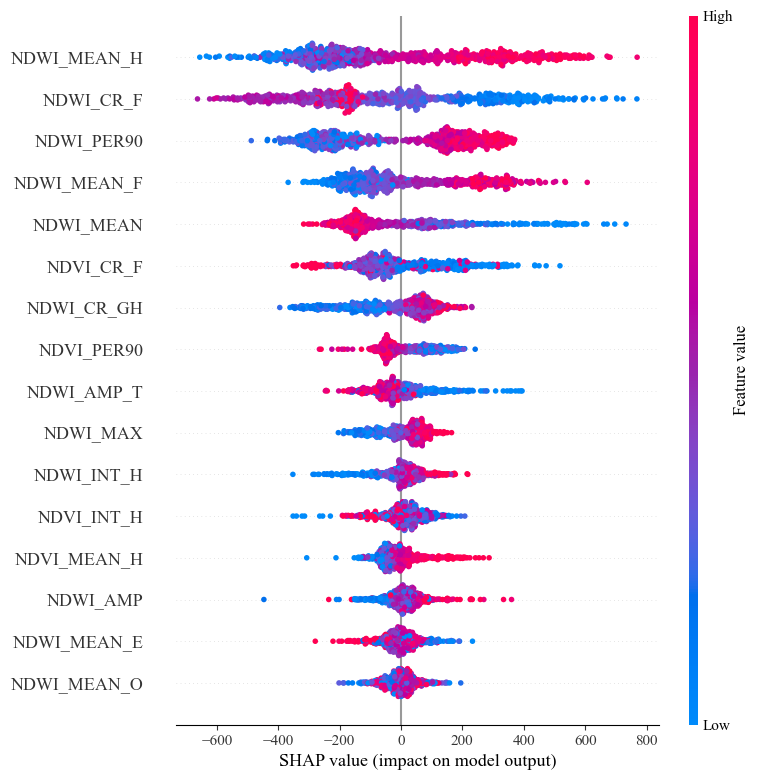

In [5]:
import shap
# 创建SHAP解释器并计算SHAP值
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_val)

# 提取特征名
feature_names = test_data.columns[np.r_[4:20]]

# 创建自定义大小的图形对象
fig, ax = plt.subplots(figsize=(5.3, 8))  # 设置图片大小 (宽, 高)

# 创建SHAP值汇总散点图（蜂群图）
shap.summary_plot(shap_values, X_val, feature_names=feature_names, show=False, plot_size=(12, 8))

# 进一步调整字体大小
ax.set_title("SHAP Summary Plot", fontsize=16)
ax.set_xlabel("SHAP Value (Impact on Model Output)", fontsize=14)
ax.set_ylabel("Feature", fontsize=14)

# 显示图
plt.show()

# 4.导出结果

In [5]:
train_data['pre_XGB_train20_21'] = np.nan
train_data.loc[train_data.index, 'pre_XGB_train20_21'] = y_pred_train
val_data['pre_XGB20_21'] = np.nan
val_data.loc[val_data.index, 'pre_XGB20_21'] = y_pred
#Write filtered data to new Excel file
train_data.to_excel('XGB_train_20_21.xlsx', index=False)
val_data.to_excel('XGB_test20_21.xlsx', index=False)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18044\1451841160.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['pre_XGB_train20_21'] = np.nan
C:\Users\DELL\AppData\Local\Temp\ipykernel_18044\1451841160.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_data['pre_XGB20_21'] = np.nan


In [6]:
val_data.head(5)

,code,start,end,yield,NDVI_INT_H,NDVI_MEAN_H,NDVI_CR_F,NDVI_PER90,NDWI_MAX,NDWI_MEAN,NDWI_INT_H,NDWI_MEAN_H,NDWI_CR_GH,NDWI_CR_F,NDWI_MEAN_F,NDWI_PER90,NDWI_MEAN_E,NDWI_MEAN_O,NDWI_AMP,NDWI_AMP_T,pre_XGB20_21
0,370725,2019,2020,6355.064896,1.611350,0.535917,-0.120953,0.519959,0.097229,0.002594,0.142453,0.050286,0.074239,-0.036662,0.049943,0.049181,-0.033332,-0.008928,0.155802,182,5426.625977
1,370724,2019,2020,5453.611036,1.467373,0.489212,-0.064143,0.491334,0.066153,-0.010071,0.053570,0.022042,0.057147,-0.024616,0.027368,0.027842,-0.031590,-0.020117,0.131217,162,4841.901855
2,370784,2019,2020,5939.512927,1.656722,0.551452,-0.125112,0.550004,0.083779,0.008458,0.190729,0.065880,0.086039,-0.045436,0.063091,0.062708,-0.029178,-0.012971,0.139596,182,6179.494629
3,370786,2019,2020,6926.642168,1.755005,0.583711,-0.155613,0.573456,0.089651,0.006321,0.208615,0.071312,0.087729,-0.051874,0.066346,0.069891,-0.041059,-0.012786,0.148002,182,6431.614258
4,370785,2019,2020,5981.468282,1.913071,0.633837,-0.161976,0.638263,0.088848,0.007736,0.241267,0.081329,0.085117,-0.045273,0.072738,0.081148,-0.050982,-0.015218,0.160553,182,6798.942871


In [34]:
#Write filtered data to new Excel file
val_data.to_excel('迭代30次追加XGB预测值-验证集.xlsx', index=False)
train_data.to_excel('迭代30次追加XGB预测值-训练集+测试集.xlsx', index=False)

In [33]:
val_data

,code,ENG_NAME,startyear,year,yield,Heading stage_mean,Heading stage_integral,Mean,Max,Change rate from greening stage to heading stage,Grain filling period change rate,The difference between peak and valley and maximum value,Vegetative growth phase change rate,Time from peak to trough to max,Average value during grouting period,Greening stage-joining stage change rate,Percentile 75,Percentile 90,Average value at emergence stage,Overwintering period average,Difference between overwintering period and emergence period,Ratio of overwintering period and emergence period,生殖生长期NDVI变化速率,抽穗期NDWI均值,抽穗期NDWI积分,NDWI总均值,NDWI最大值,返青期到抽穗期NDWI变化速率,灌浆期NDWI变化速率,NDWI峰谷与最大值之差,营养生长期NDWI变化速率,NDWI峰谷到max的时间,灌浆期NDWI均值,返青期-拔节期NDWI变化速率,NDWI百分位数75,NDWI百分位数90,NDWI出苗期均值,NDWI越冬期均值,NDWI越冬期与出苗期差值,NDWI越冬期与出苗期比值,生殖生长期NDWI变化速率,省,pre_XGB_1,pre_XGB_2,pre_XGB_3,pre_XGB_4,pre_XGB_5,pre_XGB_6,pre_XGB_7,pre_XGB_8,pre_XGB_9,pre_XGB_10,pre_XGB_11,pre_XGB_12,pre_XGB_13,pre_XGB_14,pre_XGB_15,pre_XGB_16,pre_XGB_17,pre_XGB_18,pre_XGB_19,pre_XGB_20,pre_XGB_21,pre_XGB_22,pre_XGB_23,pre_XGB_24,pre_XGB_25,pre_XGB_26,pre_XGB_27,pre_XGB_28,pre_XGB_29,pre_XGB_30
0,415099,济源市,2020,2021,6035.747021,0.610345,1.219689,0.428417,0.615604,0.002661,0.137651,0.335785,0.002224,151,0.051589,0.058267,0.516875,0.605246,0.325487,0.371346,-0.045859,0.876505,0.004318,0.070000,0.150000,0.020000,0.090000,0.000000,0.060000,0.120000,0.000000,151,0.030000,0.030000,0.040000,0.070000,0.000000,-0.020000,0.020000,-0.150000,0.000000,Henan Province,5122.246582,5036.204102,5201.556641,5129.728027,5073.355957,5123.036133,5069.163086,5121.119141,5082.794434,4994.998535,5067.070801,5090.776855,5075.332031,5216.339844,4992.252441,5192.105469,5077.765137,5122.858398,5236.883789,5053.169434,5052.310059,4905.447754,4896.369141,5025.235840,5120.488770,5115.089355,4999.518555,5013.173340,5103.040039,5079.445312
1,411528,息县,2020,2021,5352.000000,0.730102,1.446661,0.547963,0.758254,0.001468,0.139776,0.283869,0.001880,151,0.048668,0.045633,0.691370,0.744678,0.431219,0.556776,-0.125557,0.774493,0.010982,0.100000,0.200000,0.030000,0.120000,0.000000,0.110000,0.150000,0.000000,151,0.040000,0.000000,0.070000,0.090000,-0.010000,0.020000,-0.030000,-0.410000,0.000000,Henan Province,6571.517578,6835.265137,6849.666016,6565.881348,6444.641113,6500.920898,6780.782227,6759.971191,6483.562500,6695.698730,6706.730469,6639.286133,6489.909668,6541.771973,6837.332520,6718.712402,6621.607910,6815.823730,6736.272949,6952.590332,6488.842773,6375.458008,6572.890137,6393.758301,6570.208984,6287.109863,6552.087891,6407.336914,6532.973633,6415.848633
2,411422,睢县,2020,2021,7398.438855,0.732315,1.461639,0.531926,0.741682,0.002329,0.231231,0.320949,0.003566,90,0.091787,0.060605,0.618703,0.717458,0.453639,0.504833,-0.051194,0.898593,0.010230,0.100000,0.200000,0.040000,0.140000,0.000000,0.080000,0.150000,0.000000,90,0.040000,0.000000,0.080000,0.100000,0.010000,0.020000,-0.010000,0.640000,0.000000,Henan Province,6628.758301,6709.466797,6369.152344,6418.609863,6321.026855,6468.879883,6503.437500,6520.970215,6464.910645,6549.576660,6474.898926,6560.624512,6351.263672,6650.622070,6566.772949,6347.195801,6521.319824,6610.225098,6470.329102,6672.811523,6453.636230,6281.841309,6387.826660,6357.260254,6344.406250,6367.512207,6347.073242,6366.621094,6407.367676,6299.501953
3,410221,杞县,2020,2021,6750.000000,0.684925,1.369228,0.485888,0.713915,0.004402,0.126774,0.345809,0.004323,80,0.051427,0.070465,0.555143,0.657806,0.426310,0.441697,-0.015387,0.965164,0.008354,0.100000,0.210000,0.040000,0.120000,0.000000,0.080000,0.130000,0.000000,80,0.030000,0.010000,0.060000,0.100000,0.020000,0.020000,0.000000,1.010000,0.000000,Henan Province,6339.471191,6024.403809,6130.398926,6095.708008,6091.015625,6056.664062,6226.267578,6074.947266,6305.659180,6254.771973,6261.145020,6462.835449,6327.419434,6274.611816,6346.099121,6239.213379,6178.206055,6323.072754,6405.553711,6310.329590,6046.055664,5998.044434,6182.839355,6295.641602,6132.780273,6154.858398,6039.480469,6281.225098

# 4.调参

## ① n_estimators

0.5763627929559144 2 14


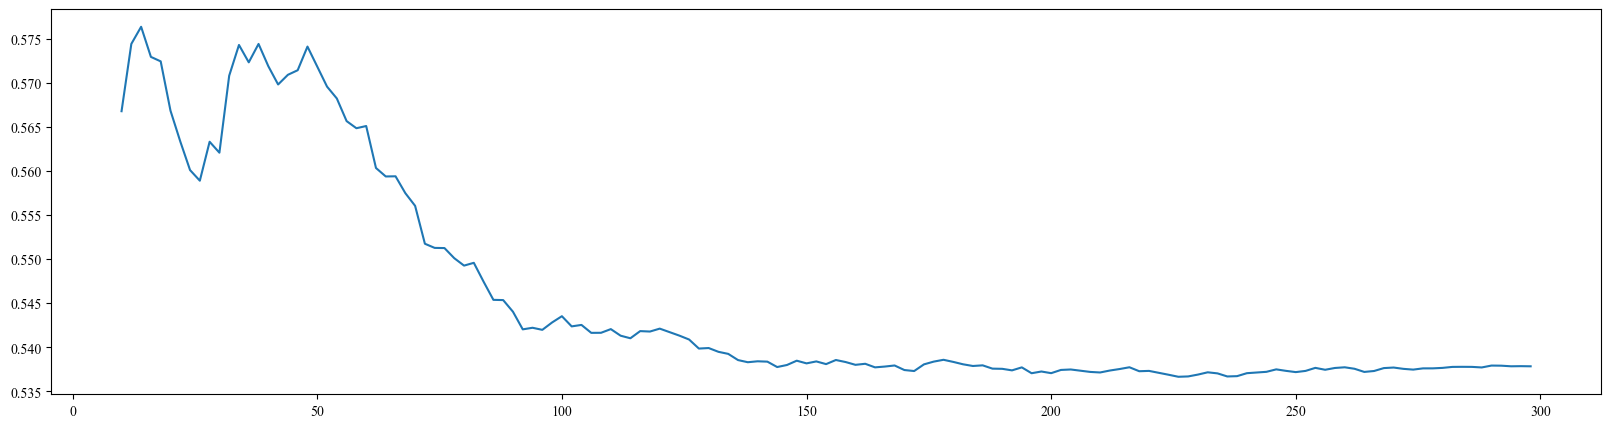

In [48]:
import pandas as pd
import numpy
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import math
from sklearn.preprocessing import MinMaxScaler, StandardScaler
train_data= data_20_21_train
test_data=data_20_21_test
val_data=test_data
X_train = train_data.iloc[:, np.r_[4:20]].values
y_train = train_data.iloc[:, 3].values
X_val = test_data.iloc[:, np.r_[4:20]].values
y_val = test_data.iloc[:, 3].values


X_train =StandardScaler().fit(X_train).transform(X_train)
X_val =StandardScaler().fit(X_val).transform(X_val)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val= scaler.transform(X_val)

#调参模型
superpa=[]
for i in numpy.arange(10,300,2):
    model=xgb.XGBRegressor(n_estimators=i,max_depth=6)#2021
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_train = model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_val, y_pred)
    r_train=np.corrcoef(y_train, y_pred_train)[0, 1]
    r = np.corrcoef(y_val, y_pred)[0, 1]
    r2=r*r
    rmse = calculate_rmse(y_pred, y_val)
    nrmse = rmse / np.mean(y_val)
    superpa.append(rmse)
print(min(superpa),superpa.index(min(superpa)),(superpa.index(min(superpa)))*2+10)
plt.figure(figsize=[20,5])
plt.plot(numpy.arange(10,300,2),superpa)#横纵坐标
plt.show()

## ②learning_rate

0.6263747027112113 87 0.187


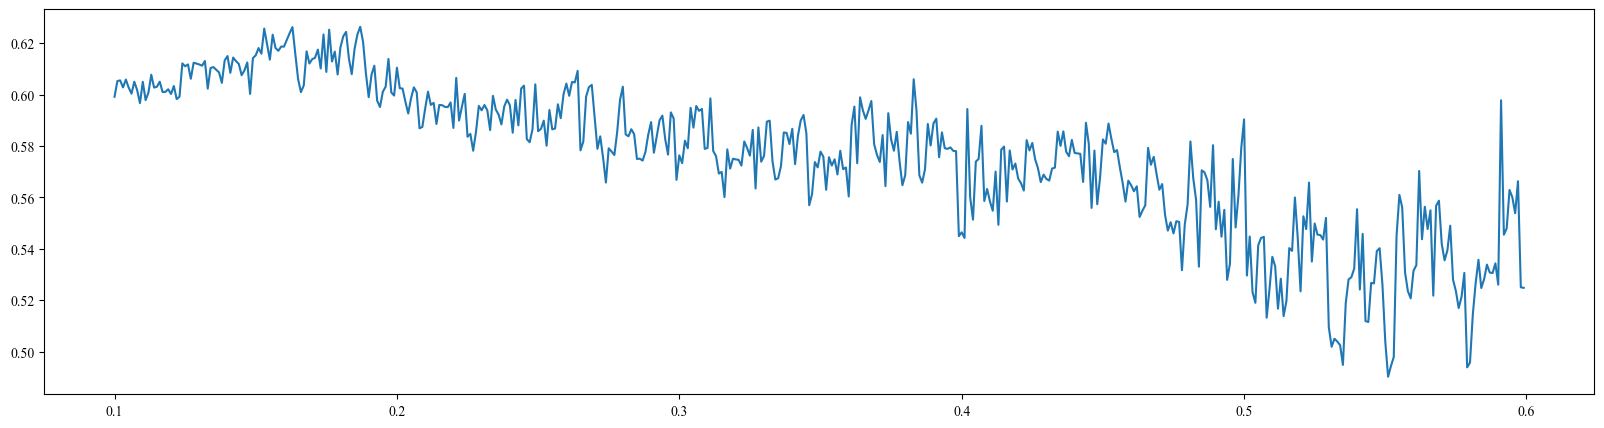

In [49]:
import numpy
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import math
from sklearn.preprocessing import MinMaxScaler, StandardScaler


def calculate_rmse(predictions, actual_values):
    return np.sqrt(np.mean((predictions - actual_values) ** 2))

df=data
train_data= data_20_21_train
test_data=data_20_21_test
val_data=test_data
X_train = train_data.iloc[:, np.r_[4:20]].values
y_train = train_data.iloc[:, 3].values
X_val = test_data.iloc[:, np.r_[4:20]].values
y_val = test_data.iloc[:, 3].values


X_train =StandardScaler().fit(X_train).transform(X_train)
X_val =StandardScaler().fit(X_val).transform(X_val)






scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val= scaler.transform(X_val)

#调参模型
superpa=[]
for i in numpy.arange(0.1,0.6,0.001):
    model=xgb.XGBRegressor(n_estimators=14,learning_rate=i,max_depth=6)#2021
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_train = model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_val, y_pred)
    r_train=np.corrcoef(y_train, y_pred_train)[0, 1]
    r = np.corrcoef(y_val, y_pred)[0, 1]
    r2=r*r
    rmse = calculate_rmse(y_pred, y_val)
    nrmse = rmse / np.mean(y_val)
    superpa.append(rmse)
print(min(superpa),superpa.index(min(superpa)),(superpa.index(min(superpa)))*0.001+0.1)
plt.figure(figsize=[20,5])
plt.plot(numpy.arange(0.1,0.6,0.001),superpa)#横纵坐标
plt.show()


## ③max_depth

0.6232050481368053 4 6


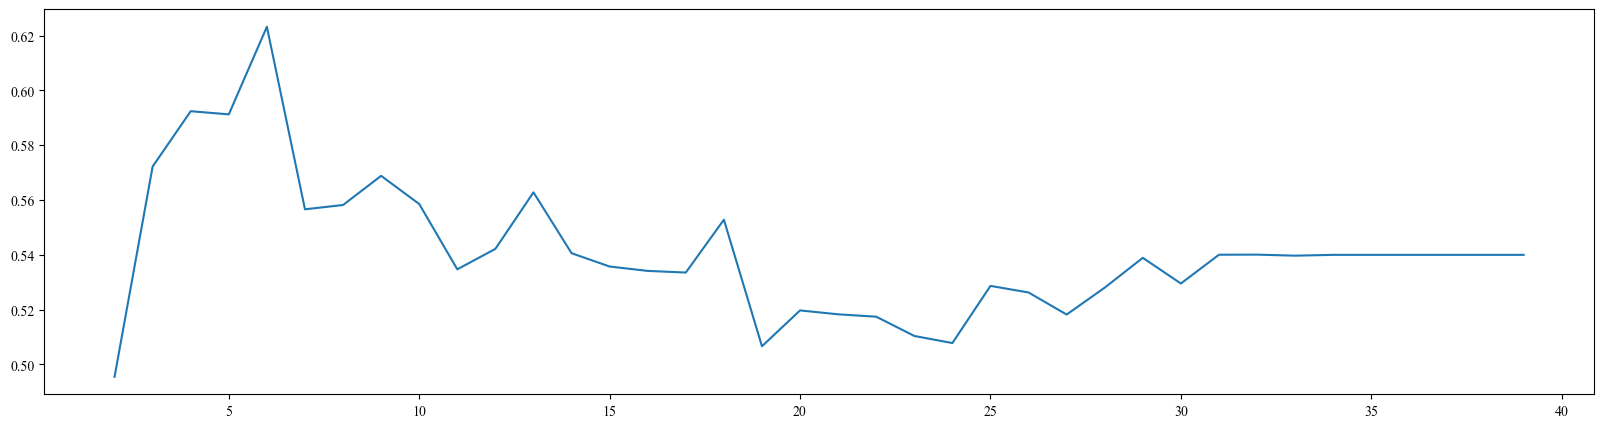

In [27]:
import numpy
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import math
from sklearn.preprocessing import MinMaxScaler, StandardScaler


def calculate_rmse(predictions, actual_values):
    return np.sqrt(np.mean((predictions - actual_values) ** 2))

df=data
train_data= data_20_21_train
test_data=data_20_21_test
val_data=test_data
X_train = train_data.iloc[:, np.r_[4:20]].values
y_train = train_data.iloc[:, 3].values
X_val = test_data.iloc[:, np.r_[4:20]].values
y_val = test_data.iloc[:, 3].values


X_train =StandardScaler().fit(X_train).transform(X_train)
X_val =StandardScaler().fit(X_val).transform(X_val)






scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val= scaler.transform(X_val)

#调参模型
superpa=[]
for i in numpy.arange(2,40,1):
    model=xgb.XGBRegressor(n_estimators=16,learning_rate=0.402,max_depth=i)#2021
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_pred_train = model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_val, y_pred)
    r_train=np.corrcoef(y_train, y_pred_train)[0, 1]
    r = np.corrcoef(y_val, y_pred)[0, 1]
    r2=r*r
    rmse = calculate_rmse(y_pred, y_val)
    nrmse = rmse / np.mean(y_val)
    superpa.append(rmse)
print(min(superpa),superpa.index(min(superpa)),(superpa.index(min(superpa)))*1+2)
plt.figure(figsize=[20,5])
plt.plot(numpy.arange(2,40,1),superpa)#横纵坐标
plt.show()
